# Richer Models for the Equity Premium

This notebook uses the fourteen Welch-Goyal predictors from Lecture 1 to forecast the equity premium. A richer model is compared to the benchmark OLS.


## 1. Imports and settings

The richer model is fitted on years up to `TRAIN_END`, its hyperparameters are chosen on the years up to `VALID_END`, and everything after that is the test block, used once at the end.

In [168]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore")

pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True

TRAIN_END = "1980"      # last year used to fit the richer model
VALID_END = "2000"      # last year used to choose its hyperparameters
RANDOM_SEED = 710       # fixed so every run of this notebook is identical

BLUE = "#003865"
GREEN = "#64A70B"
GOLD = "#F2A900"
RED = "#DA291C"

## 2. Data

The annual sheet of the Welch-Goyal workbook, exactly as in Lecture 3.

In [169]:
data_path = "PredictorData2023.xlsx"

annual = pd.read_excel(data_path, sheet_name="Annual")
annual["date"] = pd.to_datetime(annual["yyyy"].astype(str), format="%Y")
annual["date"] = annual["date"].dt.to_period("Y").dt.to_timestamp("Y")
annual = annual.set_index("date").sort_index()

print(f"Raw workbook: {annual.shape[0]} years, {annual.index.min().year}-{annual.index.max().year}")

Raw workbook: 153 years, 1871-2023


### 2.1 The predictor set

The workbook stores raw levels, so the fourteen standard predictors have to be constructed:

| Predictor | Construction | Raw columns |
|---|---|---|
| `dividend_price` | $\log(D12) - \log(Index)$ | `D12`, `Index` |
| `dividend_yield` | $\log(D12_t) - \log(Index_{t-1})$ | `D12`, `Index` |
| `earnings_price` | $\log(E12) - \log(Index)$ | `E12`, `Index` |
| `dividend_payout` | $\log(D12) - \log(E12)$ | `D12`, `E12` |
| `stock_variance` | level | `svar` |
| `book_market` | level | `b/m` |
| `net_equity_issuance` | level | `ntis` |
| `treasury_bill` | level | `tbl` |
| `long_term_yield` | level | `lty` |
| `long_term_return` | level | `ltr` |
| `term_spread` | `lty` $-$ `tbl` | `lty`, `tbl` |
| `default_yield_spread` | `BAA` $-$ `AAA` | `BAA`, `AAA` |
| `default_return_spread` | `corpr` $-$ `ltr` | `corpr`, `ltr` |
| `inflation` | level | `infl` |


In [170]:
annual["dividend_price"] = np.log(annual["D12"]) - np.log(annual["Index"])
annual["dividend_yield"] = np.log(annual["D12"]) - np.log(annual["Index"].shift(1))
annual["earnings_price"] = np.log(annual["E12"]) - np.log(annual["Index"])
annual["dividend_payout"] = np.log(annual["D12"]) - np.log(annual["E12"])
annual["stock_variance"] = annual["svar"]
annual["book_market"] = annual["b/m"]
annual["net_equity_issuance"] = annual["ntis"]
annual["treasury_bill"] = annual["tbl"]
annual["long_term_yield"] = annual["lty"]
annual["long_term_return"] = annual["ltr"]
annual["term_spread"] = annual["lty"] - annual["tbl"]
annual["default_yield_spread"] = annual["BAA"] - annual["AAA"]
annual["default_return_spread"] = annual["corpr"] - annual["ltr"]
annual["inflation"] = annual["infl"]

PREDICTORS = [
    "dividend_price", "dividend_yield", "earnings_price", "dividend_payout",
    "stock_variance", "book_market", "net_equity_issuance", "treasury_bill",
    "long_term_yield", "long_term_return", "term_spread", "default_yield_spread",
    "default_return_spread", "inflation",
]

print(f"Predictors: {len(PREDICTORS)}")

Predictors: 14


### 2.2 Target and benchmark forecast

Predictors observed at the end of year $t$ forecast the equity premium realized in year $t+1$.

$$x_t \quad \text{predicts} \quad r_{t+1}.$$

The *prevailing mean* is the average premium realized strictly before the forecast date. It is the benchmark the equity-premium literature.

In [171]:
annual["log_market_return"] = np.log((annual["Index"] + annual["D12"]) / annual["Index"].shift(1))
annual["log_risk_free"] = np.log1p(annual["Rfree"])
annual["equity_premium"] = annual["log_market_return"] - annual["log_risk_free"]
annual["equity_premium_next_year"] = annual["equity_premium"].shift(-1)

target = "equity_premium_next_year"
analysis = annual[PREDICTORS + [target]].dropna().copy()

# shift(1) enforces "strictly before": the benchmark for year t may not contain
# the premium it is being asked to forecast.
analysis["prevailing_mean"] = analysis[target].expanding().mean().shift(1)
analysis = analysis.dropna()

print(f"Estimation sample: {len(analysis)} years, "
      f"{analysis.index.min().year}-{analysis.index.max().year}")

analysis[["dividend_price", "term_spread", "net_equity_issuance", target, "prevailing_mean"]].head()

Estimation sample: 96 years, 1927-2022


,dividend_price,term_spread,net_equity_issuance,equity_premium_next_year,prevailing_mean
date,,,,,
1927-12-31,-3.1327,-1.0000e-04,0.0765,0.3184,0.2821
1928-12-31,-3.3551,-8.6000e-03,0.0631,-0.1279,0.3002
1929-12-31,-3.0962,3.7000e-03,0.1635,-0.2974,0.1575
1930-12-31,-2.7507,1.8200e-02,0.1139,-0.5496,0.0438
1931-12-31,-2.2928,1.6600e-02,-0.0129,-0.1067,-0.0749


## 3. Training, validation, and test blocks

The split is chronological:

- **training** --- fit the richer model;
- **validation** --- choose the richer model's hyperparameters;
- **test** --- evaluate once, at the end.

In [172]:
train = analysis.loc[:TRAIN_END]
valid = analysis.loc[str(int(TRAIN_END) + 1):VALID_END]
test = analysis.loc[str(int(VALID_END) + 1):]
train_valid = analysis.loc[:VALID_END]


def standardize(block, fitted_on):
    """Standardize `block` using the mean and standard deviation of `fitted_on`."""
    return (block[PREDICTORS] - fitted_on[PREDICTORS].mean()) / fitted_on[PREDICTORS].std(ddof=0)


X_train = standardize(train, fitted_on=train)
X_valid = standardize(valid, fitted_on=train)
X_test = standardize(test, fitted_on=train)
X_train_valid = standardize(train_valid, fitted_on=train)

y_train, y_valid, y_test = train[target], valid[target], test[target]
y_train_valid = train_valid[target]

for name, block in [("training", train), ("validation", valid), ("test", test)]:
    print(f"{name:<11}: {block.index.min().year}-{block.index.max().year}  {len(block):>2} years")

training   : 1927-1980  54 years
validation : 1981-2000  20 years
test       : 2001-2022  22 years


## 4. The benchmarks

Two forecasts to beat:

- the **prevailing mean**, which ignores the predictors entirely;
- **OLS on all fourteen predictors**, fitted on training plus validation.

The training $R^2$ below is measured on the years OLS was fitted to, so it is a description of fit, not evidence of forecasting ability.

In [173]:
ols_benchmark = LinearRegression().fit(X_train_valid, y_train_valid)

print(f"OLS benchmark fitted on {train_valid.index.min().year}-{train_valid.index.max().year} "
      f"({len(train_valid)} years, {len(PREDICTORS)} coefficients)")
print(f"  observations per coefficient : {len(train_valid) / len(PREDICTORS):.1f}")
print(f"  in-sample R-squared          : {ols_benchmark.score(X_train_valid, y_train_valid):.4f}")
print(f"  largest |coefficient|        : {np.abs(ols_benchmark.coef_).max():.4f}")
print(f"  standard deviation of y      : {y_train_valid.std():.4f}")

pd.Series(ols_benchmark.coef_, index=PREDICTORS).sort_values().round(4)

OLS benchmark fitted on 1927-2000 (74 years, 14 coefficients)
  observations per coefficient : 5.3
  in-sample R-squared          : 0.2360
  largest |coefficient|        : 0.0563
  standard deviation of y      : 0.1916


net_equity_issuance     -0.0563
default_yield_spread    -0.0491
dividend_payout         -0.0240
treasury_bill           -0.0209
long_term_yield         -0.0148
dividend_price          -0.0068
inflation               -0.0058
default_return_spread   -0.0035
earnings_price           0.0124
long_term_return         0.0125
dividend_yield           0.0159
stock_variance           0.0189
term_spread              0.0252
book_market              0.0356
dtype: float64

## 5. The richer model

A regression tree, fitted on the training block. Two hyperparameters control how large its partition may grow, and both are chosen on the validation block:

| Model | Tuned here | What it controls |
|---|---|---|
| `DecisionTreeRegressor` | `max_depth`, `min_samples_leaf` | how deep the tree may grow, and how few years may sit in one leaf |
| `RandomForestRegressor` | `max_depth`, `min_samples_leaf`, `max_features` | the same, plus how many predictors each split may consider |
| `Ridge` | `alpha` | the $\ell_2$ penalty on coefficient size |
| `Lasso` | `alpha` | the $\ell_1$ penalty, which also selects predictors |

The fitted model is called `richer_model`. Section 6 evaluates whatever `richer_model` holds, so the last three rows can be swapped in without changing anything downstream.

In [174]:
# Every combination of the two hyperparameters is fitted on the training block
# and scored on the validation block. The lowest validation MSE wins.
MAX_DEPTHS = [1, 2, 3, 4, 5]
MIN_SAMPLES_LEAF = [2, 4, 6, 8, 10]

fitted_trees = []
search_rows = []

for max_depth in MAX_DEPTHS:
    for min_samples_leaf in MIN_SAMPLES_LEAF:
        tree = DecisionTreeRegressor(
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=RANDOM_SEED,
        ).fit(X_train, y_train)

        fitted_trees.append(tree)
        search_rows.append({
            "max_depth": max_depth,
            "min_samples_leaf": min_samples_leaf,
            "validation_mse": mean_squared_error(y_valid, tree.predict(X_valid)),
        })

search = pd.DataFrame(search_rows)
best = int(search["validation_mse"].idxmin())   # rows are in the same order as fitted_trees

# The winner is kept.
richer_model = fitted_trees[best]
richer_label = "Decision tree"

print(f"{richer_label}, fitted on {train.index.min().year}-{train.index.max().year}, "
      f"tuned on {valid.index.min().year}-{valid.index.max().year}\n")
print(f"  chosen max_depth        : {search.loc[best, 'max_depth']}")
print(f"  chosen min_samples_leaf : {search.loc[best, 'min_samples_leaf']}")
print(f"  validation MSE          : {search['validation_mse'].min():.5f}"
      f"   (worst candidate {search['validation_mse'].max():.5f})")
print(f"  training R-squared      : {richer_model.score(X_train, y_train):.4f}\n")

search.sort_values("validation_mse").head(8).round(5)




Decision tree, fitted on 1927-1980, tuned on 1981-2000

  chosen max_depth        : 1
  chosen min_samples_leaf : 2
  validation MSE          : 0.01549   (worst candidate 0.06162)
  training R-squared      : 0.1979



,max_depth,min_samples_leaf,validation_mse
0,1,2,0.0155
19,4,10,0.0207
14,3,10,0.0207
9,2,10,0.0207
8,2,8,0.0207
24,5,10,0.0207
5,2,2,0.0231
6,2,4,0.0267


### 5.1 Swapping in another model

The loop is the same shape for every model: fit each candidate on the training block, score it on the validation block, keep the best fit as `richer_model`. Only the estimator and the grid change.

To use one of the models below, comment out the cell above, uncomment one block here, and re-run from section 5. `Ridge`, `Lasso`, and `RandomForestRegressor` are already imported in section 1, and section 6 needs no edit.

In [175]:
"""
# ---------------------------------------------------------------------------
# Ridge, or lasso: one hyperparameter, the penalty on coefficient size.
# ---------------------------------------------------------------------------
fitted_models = []
search_rows = []

for alpha in np.logspace(-4, 5, 60):                    # lasso: np.logspace(-4, 1, 60)
    model = Ridge(alpha=alpha).fit(X_train, y_train)    # lasso: Lasso(alpha=alpha, max_iter=200_000)

    fitted_models.append(model)
    search_rows.append({
        "alpha": alpha,
        "validation_mse": mean_squared_error(y_valid, model.predict(X_valid)),
    })

search = pd.DataFrame(search_rows)
best = int(search["validation_mse"].idxmin())

richer_model = fitted_models[best]
richer_label = "Ridge"                                  # lasso: "Lasso"

print(f"  chosen alpha   : {search.loc[best, 'alpha']:.4f}")
print(f"  validation MSE : {search['validation_mse'].min():.5f}")
"""

"""
# ---------------------------------------------------------------------------
# Random forest: three hyperparameters, so three nested loops. Each tree is
# grown on a bootstrap sample and sees max_features of the predictors at a split.
# ---------------------------------------------------------------------------
fitted_models = []
search_rows = []

for max_depth in [2, 3, 4, None]:
    for min_samples_leaf in [2, 4, 6, 8]:
        for max_features in [0.3, 0.5, 1.0]:
            forest = RandomForestRegressor(
                n_estimators=500,
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                max_features=max_features,
                random_state=RANDOM_SEED,
            ).fit(X_train, y_train)

            fitted_models.append(forest)
            search_rows.append({
                "max_depth": max_depth,
                "min_samples_leaf": min_samples_leaf,
                "max_features": max_features,
                "validation_mse": mean_squared_error(y_valid, forest.predict(X_valid)),
            })

search = pd.DataFrame(search_rows)
best = int(search["validation_mse"].idxmin())

richer_model = fitted_models[best]
richer_label = "Random forest"

print(search.loc[best])
"""

'\n# ---------------------------------------------------------------------------\n# Random forest: three hyperparameters, so three nested loops. Each tree is\n# grown on a bootstrap sample and sees max_features of the predictors at a split.\n# ---------------------------------------------------------------------------\nfitted_models = []\nsearch_rows = []\n\nfor max_depth in [2, 3, 4, None]:\n    for min_samples_leaf in [2, 4, 6, 8]:\n        for max_features in [0.3, 0.5, 1.0]:\n            forest = RandomForestRegressor(\n                n_estimators=500,\n                max_depth=max_depth,\n                min_samples_leaf=min_samples_leaf,\n                max_features=max_features,\n                random_state=RANDOM_SEED,\n            ).fit(X_train, y_train)\n\n            fitted_models.append(forest)\n            search_rows.append({\n                "max_depth": max_depth,\n                "min_samples_leaf": min_samples_leaf,\n                "max_features": max_features,\n

## 6. Out-of-sample test

The test block is used here, once. Forecast accuracy is summarized against the prevailing mean:

$$R^2_{\mathrm{OOS}} = 1 - \frac{\mathrm{MSE}_{\mathrm{model}}}{\mathrm{MSE}_{\mathrm{prevailing\ mean}}}.$$

It is zero for a model that matches the benchmark and **negative** for one that does worse.


In [176]:
def metric_row(actual, forecast, label, benchmark_mse):
    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    error = actual - forecast
    return pd.Series(
        {
            "RMSE": np.sqrt(np.mean(error**2)),
            "MAE": np.mean(np.abs(error)),
            "Bias: mean(actual - forecast)": np.mean(error),
            "OOS R2 vs prevailing mean (%)": 100 * (1 - np.mean(error**2) / benchmark_mse),
            "Distinct forecasts": len(np.unique(np.round(forecast, 10))),
        },
        name=label,
    )


test_forecasts = {
    "Prevailing mean": np.asarray(test["prevailing_mean"], dtype=float),
    f"OLS, all {len(PREDICTORS)} predictors": ols_benchmark.predict(X_test),
    richer_label: richer_model.predict(X_test),
}

benchmark_mse = mean_squared_error(y_test, test_forecasts["Prevailing mean"])

results = pd.concat(
    [metric_row(y_test, forecast, label, benchmark_mse) for label, forecast in test_forecasts.items()],
    axis=1,
).T
results["Distinct forecasts"] = results["Distinct forecasts"].astype(int)

print(f"Test block: {test.index.min().year}-{test.index.max().year} ({len(test)} years)\n")
results

Test block: 2001-2022 (22 years)



,RMSE,MAE,Bias: mean(actual - forecast),OOS R2 vs prevailing mean (%),Distinct forecasts
Prevailing mean,0.1832,0.1408,0.0106,0.0000,22
"OLS, all 14 predictors",0.1925,0.1441,-0.0177,-10.3980,22
Decision tree,0.1820,0.1374,0.0008,1.3448,1


In [177]:
ols_label = f"OLS, all {len(PREDICTORS)} predictors"
ols_mse = mean_squared_error(y_test, test_forecasts[ols_label])
richer_mse = mean_squared_error(y_test, test_forecasts[richer_label])
years_closer = int(np.sum(np.abs(y_test - test_forecasts[richer_label])
                          < np.abs(y_test - test_forecasts[ols_label])))

comparison = {
    f"Test MSE, {ols_label}": f"{ols_mse:.5f}",
    f"Test MSE, {richer_label.lower()}": f"{richer_mse:.5f}",
    "MSE reduction vs OLS": f"{100 * (1 - richer_mse / ols_mse):.2f}%",
    "Years the richer model is closer": f"{years_closer} of {len(test)}",
}

print(f"{richer_label} vs the OLS benchmark, "
      f"{test.index.min().year}-{test.index.max().year}\n")
for name, value in comparison.items():
    print(f"  {name:<36}: {value}")

Decision tree vs the OLS benchmark, 2001-2022

  Test MSE, OLS, all 14 predictors    : 0.03707
  Test MSE, decision tree             : 0.03313
  MSE reduction vs OLS                : 10.64%
  Years the richer model is closer    : 11 of 22


### 6.1 Where the difference comes from

The first figure shows the three test-block forecasts against what actually happened. The second is the Welch-Goyal diagnostic: cumulative squared error of the benchmark minus cumulative squared error of the model. A line above zero means the model is ahead cumulatively to that date; a line drifting steadily downward means the benchmark is winning.

The right panel compares the two models directly, so it is positive wherever the richer model has been the better forecaster to date.

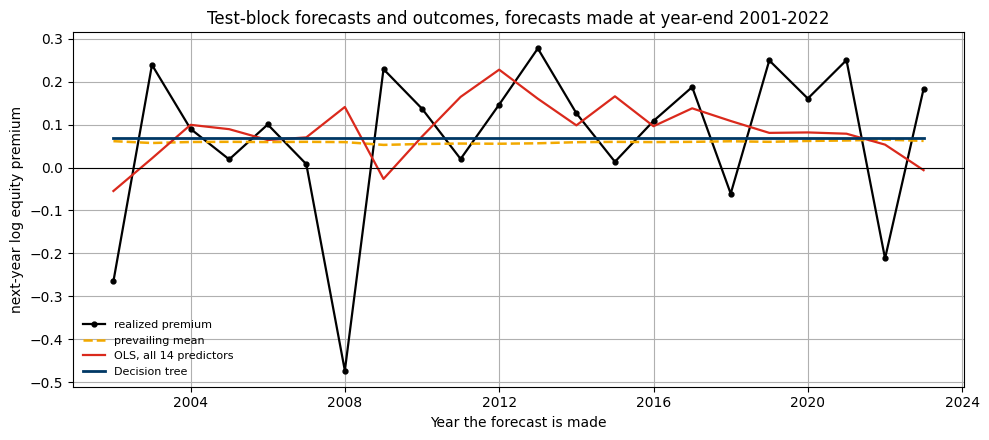

In [178]:
fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(test.index, y_test, color="black", lw=1.6, marker="o", ms=3.5, label="realized premium")
ax.plot(test.index, test_forecasts["Prevailing mean"], color=GOLD, lw=1.8, ls="--",
        label="prevailing mean")
ax.plot(test.index, test_forecasts[ols_label], color=RED, lw=1.6, label=ols_label)
ax.plot(test.index, test_forecasts[richer_label], color=BLUE, lw=2.0, label=richer_label)

ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"Test-block forecasts and outcomes, forecasts made at year-end "
             f"{test.index.min().year}-{test.index.max().year}")
ax.set_xlabel("Year the forecast is made")
ax.set_ylabel("next-year log equity premium")
ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

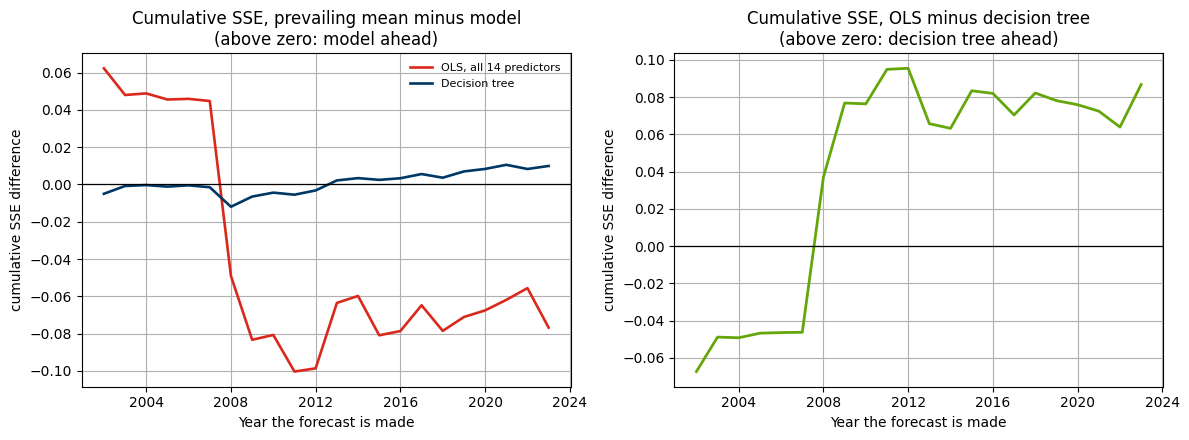

In [179]:
benchmark_error = y_test - test_forecasts["Prevailing mean"]
ols_error = y_test - test_forecasts[ols_label]
richer_error = y_test - test_forecasts[richer_label]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for error, label, colour in [(ols_error, ols_label, RED), (richer_error, richer_label, BLUE)]:
    cumulative = (benchmark_error**2).cumsum() - (error**2).cumsum()
    axes[0].plot(cumulative.index, cumulative.values, color=colour, lw=1.9, label=label)

axes[0].axhline(0, color="black", lw=0.9)
axes[0].set_title("Cumulative SSE, prevailing mean minus model\n(above zero: model ahead)")
axes[0].set_xlabel("Year the forecast is made")
axes[0].set_ylabel("cumulative SSE difference")
axes[0].legend(loc="best", frameon=False, fontsize=8)

head_to_head = (ols_error**2).cumsum() - (richer_error**2).cumsum()
axes[1].plot(head_to_head.index, head_to_head.values, color=GREEN, lw=2.0)
axes[1].axhline(0, color="black", lw=0.9)
axes[1].set_title(f"Cumulative SSE, OLS minus {richer_label.lower()}\n"
                  f"(above zero: {richer_label.lower()} ahead)")
axes[1].set_xlabel("Year the forecast is made")
axes[1].set_ylabel("cumulative SSE difference")

plt.tight_layout()
plt.show()

## 8. Swapping the richer model

Uncomment one of the blocks in section 5.1, comment out the tree, and run the notebook again. Section 6 onwards is written against `richer_model` and `richer_label`, so nothing else changes.
